# **Homework 13: Multi-Agent Reinforcement Learning**

#### **Course:** Deep Reinforcement Learning

---
## Problem 1: Nash Equilibrium (Theory)

A Nash Equilibrium (NE) represents a state where no player can improve their outcome by unilaterally changing their strategy. For our games, we'll focus on finding the mixed-strategy NE, where players choose their actions probabilistically.

### 1.1 Standard Rock-Scissors-Paper

Given the standard RSP payoff matrix:

| Player 1 | Rock | Scissors | Paper |
| :--- | :--: | :---: | :---: |
| **Rock** | 0, 0 | 1, -1 | -1, 1 |
| **Scissors**| -1, 1 | 0, 0 | 1, -1 |
| **Paper** | 1, -1 | -1, 1 | 0, 0 |


**Your Task:** Analytically derive the mixed-strategy Nash Equilibrium for this game. Show the steps for setting up the indifference equations for Player 1 and solving for Player 2's equilibrium strategy probabilities $(q_R, q_S, q_P)$. (find the Mixed Nash equilibrium of the game)

Let Player 1's mixed strategy be $sigma_1 = (p_R, p_S, p_P)$ and Player 2's be $\sigma_2 = (q_R, q_S, q_P)$. Since probabilities must sum to 1, we can express one in terms of the others:
*   $p_P = 1 - p_R - p_S$
*   $q_P = 1 - q_R - q_S$

Let $U_1(\sigma_1, \sigma_2)$ be the expected utility for Player 1, and $U_2(\sigma_1, \sigma_2)$ for Player 2. These are calculated as $\sigma_1 \cdot A \cdot \sigma_2^T$ where A is Player 1's payoff matrix.

$$
U_1(\sigma_1, \sigma_2) = \begin{pmatrix} p_R & p_S & p_P \end{pmatrix} \begin{pmatrix} 0 & 1 & -1 \\ -1 & 0 & 1 \\ 1 & -1 & 0 \end{pmatrix} \begin{pmatrix} q_R \\ q_S \\ q_P \end{pmatrix}
$$

Expanding this gives:
$$
U_1(\sigma_1, \sigma_2) = p_R(q_S - q_P) + p_S(q_P - q_R) + p_P(q_R - q_S)
$$

Substitute $p_P = 1 - p_R - p_S$ and $q_P = 1 - q_R - q_S$:
$$
U_1 = p_R(q_S - (1 - q_R - q_S)) + p_S((1 - q_R - q_S) - q_R) + (1 - p_R - p_S)(q_R - q_S)
$$
$$
U_1(p_R, p_S, q_R, q_S) = p_R(q_R + 2q_S - 1) + p_S(1 - 2q_R - q_S) + (1 - p_R - p_S)(q_R - q_S)
$$
After expanding and collecting terms:
$$
U_1(p_R, p_S, q_R, q_S) = p_R(3q_S - 1) + p_S(1 - 3q_R) + q_R - q_S
$$

$$ \frac{\partial U_1}{\partial p_R} = 3q_S - 1 $$
$$ \frac{\partial U_1}{\partial p_S} = 1 - 3q_R $$

Set these to zero to solve for $q_R$ and $q_S$:
$$ 3q_S - 1 = 0 \implies q_S = \frac{1}{3} $$
$$ 1 - 3q_R = 0 \implies q_R = \frac{1}{3} $$

Now find $q_P$:
$$ q_P = 1 - q_R - q_S = 1 - \frac{1}{3} - \frac{1}{3} = \frac{1}{3} $$

This gives Player 2's equilibrium strategy: $\sigma_2^* = (\frac{1}{3}, \frac{1}{3}, \frac{1}{3})$.

The game is zero-sum, so $U_2(\sigma_1, \sigma_2) = -U_1(\sigma_1, \sigma_2)$.
$$
U_2(p_R, p_S, q_R, q_S) = - \left[ p_R(3q_S - 1) + p_S(1 - 3q_R) + q_R - q_S \right]
$$

This gives Player 1's equilibrium strategy: $\sigma_1^* = (\frac{1}{3}, \frac{1}{3}, \frac{1}{3})$.


### 1.2 Modified Rock-Scissors-Paper

Now, consider the modified RSP game where the stakes are higher:

| Player 1 | Rock | Scissors | Paper |
| :--- | :--: | :---: | :---: |
| **Rock** | 0, 0 | 1, -1 | -2, 2 |
| **Scissors**| -1, 1 | 0, 0 | 3, -3 |
| **Paper** | 2, -2 | -3, 3 | 0, 0 |


**Your Task:** Like pervious one Derive the mixed-strategy Nash Equilibrium for this modified game.

Let Player 1's mixed strategy be $\sigma_1 = (p_R, p_S, p_P)$ and Player 2's be $\sigma_2 = (q_R, q_S, q_P)$. We use the constraints $p_P = 1 - p_R - p_S$ and $q_P = 1 - q_R - q_S$.

The new payoff matrix for Player 1 (A) is:
$$ A = \begin{pmatrix} 0 & 1 & -2 \\ -1 & 0 & 3 \\ 2 & -3 & 0 \end{pmatrix} $$

The expected utility for Player 1, $U_1(\sigma_1, \sigma_2) = \sigma_1 \cdot A \cdot \sigma_2^T$, is:
$$
U_1 = p_R(0 \cdot q_R + 1 \cdot q_S - 2 \cdot q_P) + p_S(-1 \cdot q_R + 0 \cdot q_S + 3 \cdot q_P) + p_P(2 \cdot q_R - 3 \cdot q_S + 0 \cdot q_P)
$$
$$
U_1 = p_R(q_S - 2q_P) + p_S(-q_R + 3q_P) + p_P(2q_R - 3q_S)
$$
Substitute $p_P = 1 - p_R - p_S$ and $q_P = 1 - q_R - q_S$:
$$
U_1 = p_R(q_S - 2(1 - q_R - q_S)) + p_S(-q_R + 3(1 - q_R - q_S)) + (1 - p_R - p_S)(2q_R - 3q_S)
$$
Expand the terms:
$$
U_1 = p_R(q_S - 2 + 2q_R + 2q_S) + p_S(-q_R + 3 - 3q_R - 3q_S) + (2q_R - 3q_S - 2p_Rq_R + 3p_Rq_S - 2p_Sq_R + 3p_Sq_S)
$$
$$
U_1 = p_R(2q_R + 3q_S - 2) + p_S(-4q_R - 3q_S + 3) + 2q_R - 3q_S - 2p_Rq_R + 3p_Rq_S - 2p_Sq_R + 3p_Sq_S
$$
Collect terms for $p_R$ and $p_S$:
$$
U_1(p_R, p_S, q_R, q_S) = p_R(4q_R + 6q_S - 2) + p_S(-6q_R - 6q_S + 3) + 2q_R - 3q_S
$$


To find Player 2's equilibrium strategy, we take the partial derivatives of $U_1$ with respect to Player 1's strategy variables ($p_R, p_S$) and set them to zero. This ensures Player 1 is indifferent between their choices.
$$ \frac{\partial U_1}{\partial p_R} = 6q_S - 2 $$
$$ \frac{\partial U_1}{\partial p_S} = -6q_R + 3 $$
Setting these to zero gives a system of linear equations:
$$
\begin{cases}
6q_S = 2 & (1) \\
6q_R = 3 & (2)
\end{cases}
$$
Player 2's equilibrium strategy is $\sigma_2^* = (\frac{1}{2}, \frac{1}{3}, \frac{1}{6})$.


The game is zero-sum, so Player 2's utility is $U_2 = -U_1$.
$$ U_2(p_R, p_S, q_R, q_S) = - \left[ p_R(4q_R + 6q_S - 2) + p_S(-6q_R - 6q_S + 3) + 2q_R - 3q_S \right] $$

Player 1's equilibrium strategy is $\sigma_2^* = (\frac{1}{2}, \frac{1}{3}, \frac{1}{6})$.

---
## Problem 2: Learning by Observation - Fictitious Play (Implementation)

Fictitious Play is an intuitive learning algorithm where each agent models its opponent as playing a stationary strategy defined by the historical frequency of their past actions. The agent then plays a **best response** to this belief.

### 2.1 Implementation

**Your Task:** Implement the `simulate_fictitious_play` function below. It should take the payoff matrices for both players and the number of iterations as input. At each step, each player should choose the action that maximizes their expected payoff given the history of the opponent's plays.

**Algorithm:** At each time step $t > 0$, Player $i$ forms a belief that their opponent ($-i$) will play each action $a'$ with a probability equal to its historical frequency. The agent then chooses an action $a_i^*$ that is a best response to this belief.

Let $C_{t-1}(a_{-i})$ be the count of times opponent $-i$ has played action $a_{-i}$ up to step $t-1$. Player $i$'s best response is:
$$a_{i,t}^* = \arg\max_{a_i \in A_i} \sum_{a_{-i} \in A_{-i}} u_i(a_i, a_{-i}) \cdot \frac{C_{t-1}(a_{-i})}{t-1}$$

**Note on Tie-Breaking:** If multiple actions yield the same maximal expected payoff, your agent should choose one of these best responses uniformly at random.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def simulate_fictitious_play(A, B, iterations):
    """
    Simulates Fictitious Play for two players in a normal-form game.

    Args:
        A (np.ndarray): Payoff matrix for Player 1.
        B (np.ndarray): Payoff matrix for Player 2.
        iterations (int): The number of rounds to play.

    Returns:
        tuple: A tuple containing:
            - p1_freq_history (np.ndarray): History of Player 1's action frequencies.
            - p2_freq_history (np.ndarray): History of Player 2's action frequencies.
    """
    actions_p1 = np.zeros(A.shape[0])
    actions_p2 = np.zeros(B.shape[0])
    p1_freq_history = []
    p2_freq_history = []
    for it in range(iterations):
        # Player 1's turn
        if it == 0:
            action_p1 = 0
        else:
            freqs_p2 = actions_p2 / np.sum(actions_p2)
            expected_payoffs_p1 = A @ freqs_p2
            action_p1 = np.argmax(expected_payoffs_p1)
        actions_p1[action_p1] += 1

        # Player 2's turn
        if it == 0:
            action_p2 = 0
        else:
            freqs_p1 = actions_p1 / np.sum(actions_p1)
            expected_payoffs_p2 = B @ freqs_p1
            action_p2 = np.argmax(expected_payoffs_p2)
        actions_p2[action_p2] += 1

        if it % 10 == 0:
            p1_freq_history.append(actions_p1 / np.sum(actions_p1))
            p2_freq_history.append(actions_p2 / np.sum(actions_p2))
            
    return np.array(p1_freq_history), np.array(p2_freq_history)

# --- Payoff Matrices ---
A_std = np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])
A_mod = np.array([[0, 1, -2], [-1, 0, 3], [2, -3, 0]])

### 2.2 Analysis

**Your Task:**
1.  Run your simulation for **1,000,000 iterations** on both the **standard** and **modified** RSP games.
2.  Generate two plots, one for each game. Each plot should show the evolution of Players action frequencies over time and include horizontal lines indicating the theoretical NE probabilities you calculated in Problem 1.
3.  **Analyze your results:** Do the action frequencies converge? If so, do they converge to the Nash Equilibrium? Explain the observed behavior.

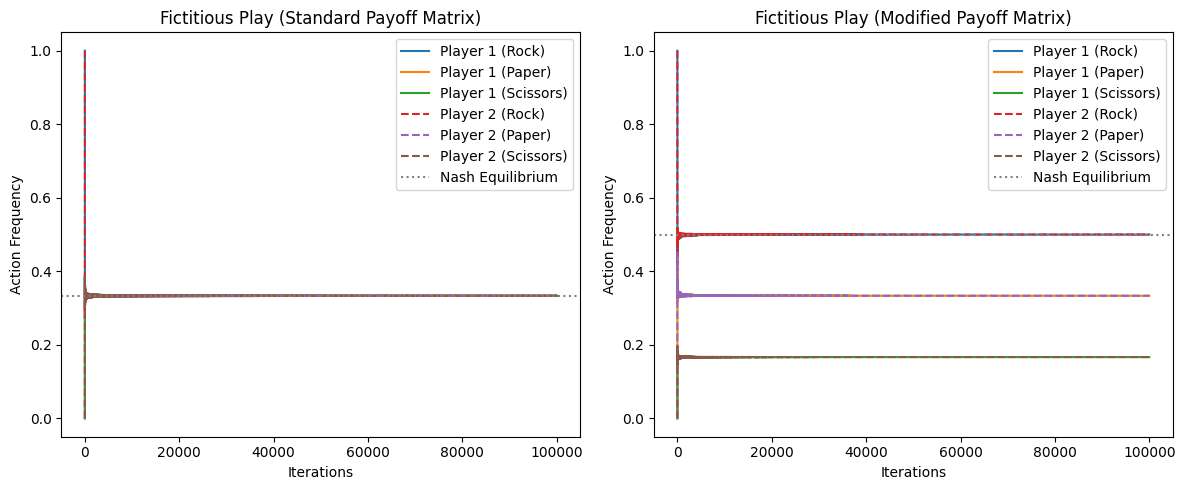

In [ ]:
freqs_p1_std, freqs_p2_std = simulate_fictitious_play(A_std, -A_std.T, 1_000_000)
freqs_p1_mod, freqs_p2_mod = simulate_fictitious_play(A_mod, -A_mod.T, 1_000_000)

# --- Plotting ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(freqs_p1_std[:, 0], label='Player 1 (Rock)')
plt.plot(freqs_p1_std[:, 1], label='Player 1 (Paper)')
plt.plot(freqs_p1_std[:, 2], label='Player 1 (Scissors)')
plt.plot(freqs_p2_std[:, 0], '--', label='Player 2 (Rock)')
plt.plot(freqs_p2_std[:, 1], '--', label='Player 2 (Paper)')
plt.plot(freqs_p2_std[:, 2], '--', label='Player 2 (Scissors)')

plt.axhline(1/3, color='gray', linestyle=':', label='Nash Equilibrium')

plt.title('Fictitious Play (Standard Payoff Matrix)')
plt.xlabel('Iterations')
plt.ylabel('Action Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs_p1_mod[:, 0], label='Player 1 (Rock)')
plt.plot(freqs_p1_mod[:, 1], label='Player 1 (Paper)')
plt.plot(freqs_p1_mod[:, 2], label='Player 1 (Scissors)')
plt.plot(freqs_p2_mod[:, 0], '--', label='Player 2 (Rock)')
plt.plot(freqs_p2_mod[:, 1], '--', label='Player 2 (Paper)')
plt.plot(freqs_p2_mod[:, 2], '--', label='Player 2 (Scissors)')

plt.axhline(1/2, color='gray', linestyle=':', label='Nash Equilibrium')
plt.axhline(1/3, color='gray', linestyle=':', label='Nash Equilibrium')
plt.axhline(1/6, color='gray', linestyle=':', label='Nash Equilibrium')
plt.title('Fictitious Play (Modified Payoff Matrix)')
plt.xlabel('Iterations')
plt.ylabel('Action Frequency')
plt.legend()

plt.tight_layout()
plt.show()

Converged to Nash Equilibria:
- Standard Payoff Matrix: Both players converge to (1/3, 1/3, 1/3)
- Modified Payoff Matrix: Both players converge to (1/2, 1/3, 1/6)

---
## Problem 3: Fictitious Play with Exploration (Implementation)

Our Fictitious Play agent is purely exploitative. In Reinforcement Learning, we know the importance of the **exploration-exploitation tradeoff**. Let's create an $\epsilon$-greedy version of Fictitious Play.

### 3.1 Implementation

**Your Task:** Create a new function, `simulate_epsilon_greedy_fp`. This function should be similar to your Fictitious Play implementation but include an `epsilon` parameter. At each step, with probability `epsilon`, the agent should choose a random action (explore). With probability `1-epsilon`, it should play the best response (exploit).

In [18]:
def simulate_epsilon_greedy_fp(A, B, iterations, epsilon):
    """
    Simulates epsilon-greedy Fictitious Play.
    """
    actions_p1 = np.zeros(A.shape[0])
    actions_p2 = np.zeros(B.shape[0])
    p1_freq_history = []
    p2_freq_history = []
    for it in range(iterations):
        # Player 1's turn
        if it == 0 or np.random.rand() < epsilon:
            action_p1 = np.random.randint(A.shape[0])
        else:
            freqs_p2 = actions_p2 / np.sum(actions_p2)
            expected_payoffs_p1 = A @ freqs_p2
            action_p1 = np.argmax(expected_payoffs_p1)
            
        actions_p1[action_p1] += 1

        # Player 2's turn
        if it == 0 or np.random.rand() < epsilon:
            action_p2 = np.random.randint(B.shape[0])
        else:
            freqs_p1 = actions_p1 / np.sum(actions_p1)
            expected_payoffs_p2 = B @ freqs_p1
            action_p2 = np.argmax(expected_payoffs_p2)
        actions_p2[action_p2] += 1

        if it % 10 == 0:
            p1_freq_history.append(actions_p1 / np.sum(actions_p1))
            p2_freq_history.append(actions_p2 / np.sum(actions_p2))
            
    return np.array(p1_freq_history), np.array(p2_freq_history)

# --- Payoff Matrices ---
A_std = np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])
A_mod = np.array([[0, 1, -2], [-1, 0, 3], [2, -3, 0]])


### 3.2 Analysis

**Your Task:**
1.  Run the `simulate_epsilon_greedy_fp` function on the **modified** RSP game for **1,000,000 iterations** with three different `epsilon` values: `0.01`, `0.1`, and `0.3`.
2.  Plot the results for each simulation.
3.  **Analyze your results:** How does `epsilon` affect the learning dynamics? Does the agent's strategy still converge to the NE? If not, to what does it converge? Discuss the impact of exploration in this multi-agent context.

Simulating with epsilon = 0.1
Simulating with epsilon = 0.01
Simulating with epsilon = 0.001


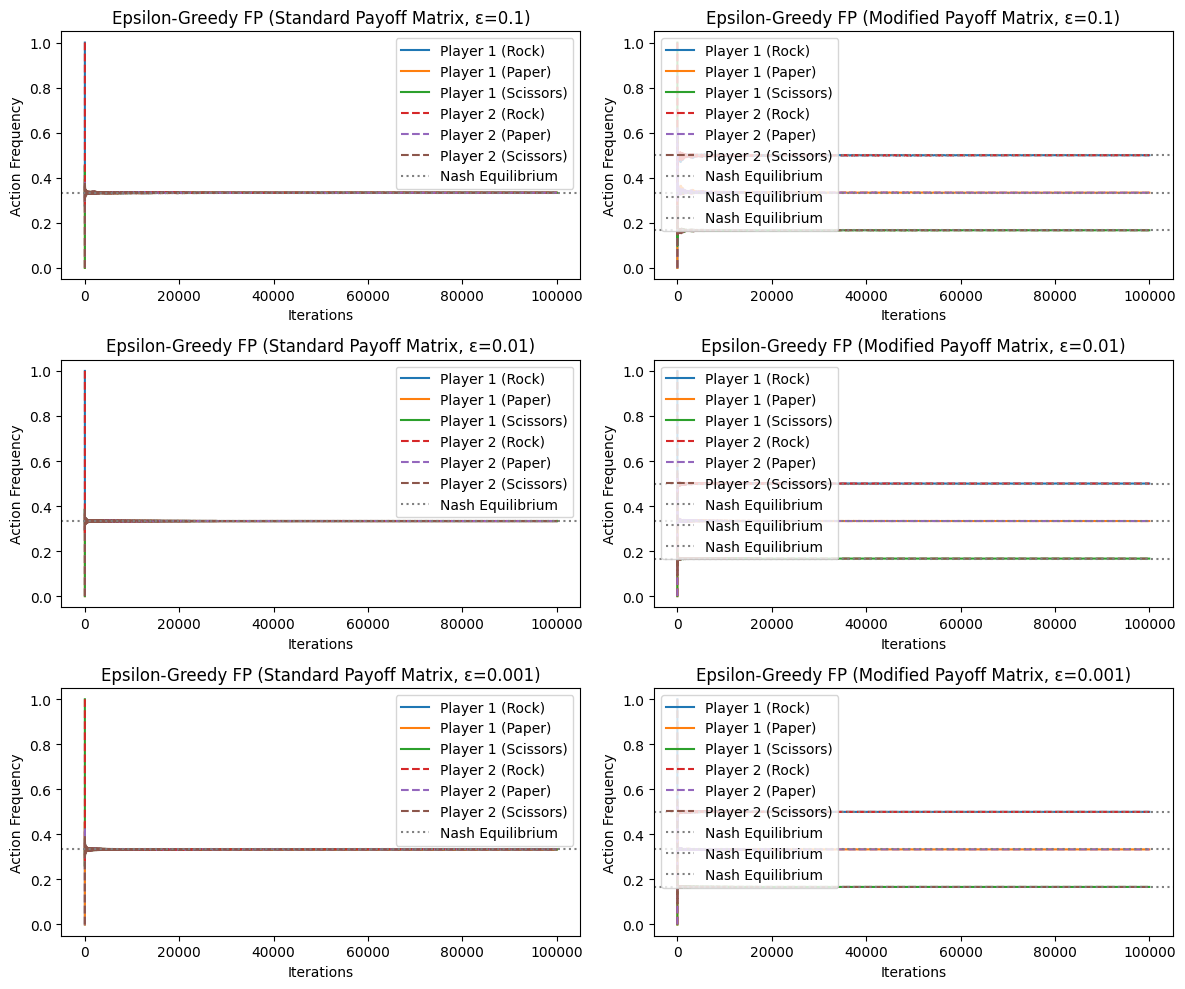

In [23]:
epsilons = [0.1, 0.01, 0.001]

freqs_std = []
freqs_mod = []
for epsilon in epsilons:
    print(f"Simulating with epsilon = {epsilon}")
    freqs_p1_std, freqs_p2_std = simulate_epsilon_greedy_fp(A_std, -A_std.T, 1_000_000, epsilon)
    freqs_p1_mod, freqs_p2_mod = simulate_epsilon_greedy_fp(A_mod, -A_mod.T, 1_000_000, epsilon)

    freqs_std.append((freqs_p1_std, freqs_p2_std))
    freqs_mod.append((freqs_p1_mod, freqs_p2_mod))

plt.figure(figsize=(12, 10))
for i, epsilon in enumerate(epsilons):
    plt.subplot(3, 2, 2*i + 1)
    plt.plot(freqs_std[i][0][:, 0], label='Player 1 (Rock)')
    plt.plot(freqs_std[i][0][:, 1], label='Player 1 (Paper)')
    plt.plot(freqs_std[i][0][:, 2], label='Player 1 (Scissors)')
    plt.plot(freqs_std[i][1][:, 0], '--', label='Player 2 (Rock)')
    plt.plot(freqs_std[i][1][:, 1], '--', label='Player 2 (Paper)')
    plt.plot(freqs_std[i][1][:, 2], '--', label='Player 2 (Scissors)')

    plt.axhline(1/3, color='gray', linestyle=':', label='Nash Equilibrium')

    plt.title(f'Epsilon-Greedy FP (Standard Payoff Matrix, ε={epsilon})')
    plt.xlabel('Iterations')
    plt.ylabel('Action Frequency')
    plt.legend()

    plt.subplot(3, 2, 2*i + 2)
    plt.plot(freqs_mod[i][0][:, 0], label='Player 1 (Rock)')
    plt.plot(freqs_mod[i][0][:, 1], label='Player 1 (Paper)')
    plt.plot(freqs_mod[i][0][:, 2], label='Player 1 (Scissors)')
    plt.plot(freqs_mod[i][1][:, 0], '--', label='Player 2 (Rock)')
    plt.plot(freqs_mod[i][1][:, 1], '--', label='Player 2 (Paper)')
    plt.plot(freqs_mod[i][1][:, 2], '--', label='Player 2 (Scissors)')

    plt.axhline(1/2, color='gray', linestyle=':', label='Nash Equilibrium')
    plt.axhline(1/3, color='gray', linestyle=':', label='Nash Equilibrium')
    plt.axhline(1/6, color='gray', linestyle=':', label='Nash Equilibrium')
    
    plt.title(f'Epsilon-Greedy FP (Modified Payoff Matrix, ε={epsilon})')
    plt.xlabel('Iterations')
    plt.ylabel('Action Frequency')
    plt.legend()
plt.tight_layout()
plt.show()

---
## Problem 4: Learning from "What If" - Regret Matching (Implementation & Theory)

Regret Matching is a powerful no-regret learning algorithm. Instead of playing a best response to history, an agent's probability of choosing an action is proportional to the positive **regret** for not having chosen that action in the past. The key property of regret matching is that the **average strategy** over time converges to a Nash Equilibrium.

### 4.1 Implementation

**Your Task:** Implement the `simulate_regret_matching` function below.

**Algorithm:** Regret Matching works in two steps. First, update the cumulative regrets. Second, determine the next round's strategy.

1.  **Regret Calculation:** After playing action $a_i$ against opponent's action $a_{-i}$, the cumulative regret $R_t(s)$ for *not* having played action $s \in A_i$ is updated as follows:
    $$R_t(s) = R_{t-1}(s) + u_i(s, a_{-i}) - u_i(a_i, a_{-i})$$

2.  **Strategy Calculation:** The probability of playing action $s$ in the next round is proportional to its positive cumulative regret, $R_t^+(s) = \max(0, R_t(s))$.
    $$p_{t+1}(s) = \frac{R_t^+(s)}{\sum_{s' \in A_i} R_t^+(s')}$$
    If the sum of positive regrets is zero, play uniformly at random.

In [25]:
def simulate_regret_matching(A, B, iterations):
    """
    Simulates Regret Matching for two players.

    Returns:
        tuple: A tuple containing:
            - p1_avg_strat_hist (np.ndarray): History of Player 1's average strategy.
            - p1_inst_strat_hist (np.ndarray): History of Player 1's instantaneous strategy.
    """
    num_actions = A.shape[0]
    
    ### YOUR CODE HERE ###
    # Initialize regrets, strategy sums, and history lists
    # Loop for iterations
    # Calculate the current strategy based on positive regrets
    #   (If sum of positive regrets is 0, play uniformly random)
    # Store the instantaneous strategy and add to the strategy sum
    # Choose actions based on the current strategies
    # Update regrets for ALL actions based on the outcome
    # Periodically record the average and instantaneous strategies
    regrets_p1 = np.zeros(num_actions)
    regrets_p2 = np.zeros(num_actions)
    strategy_sum_p1 = np.zeros(num_actions)
    strategy_sum_p2 = np.zeros(num_actions)
    p1_avg_strat_hist = []
    p1_inst_strat_hist = []
    for it in range(iterations):
        # Player 1's turn
        if it == 0:
            strategy_p1 = np.ones(num_actions) / num_actions
        else:
            positive_regrets_p1 = np.maximum(regrets_p1, 0)
            if np.sum(positive_regrets_p1) > 0:
                strategy_p1 = positive_regrets_p1 / np.sum(positive_regrets_p1)
            else:
                strategy_p1 = np.ones(num_actions) / num_actions
                
        action_p1 = np.random.choice(num_actions, p=strategy_p1)
        strategy_sum_p1 += strategy_p1
        p1_inst_strat_hist.append(strategy_p1)

        # Player 2's turn
        if it == 0:
            strategy_p2 = np.ones(num_actions) / num_actions
        else:
            positive_regrets_p2 = np.maximum(regrets_p2, 0)
            if np.sum(positive_regrets_p2) > 0:
                strategy_p2 = positive_regrets_p2 / np.sum(positive_regrets_p2)
            else:
                strategy_p2 = np.ones(num_actions) / num_actions
                
        action_p2 = np.random.choice(num_actions, p=strategy_p2)
        strategy_sum_p2 += strategy_p2

        actual_payoff_p1 = A[action_p1, action_p2]
        for a in range(num_actions):
            hypothetical_payoff = A[a, action_p2]
            regrets_p1[a] += hypothetical_payoff - actual_payoff_p1

        actual_payoff_p2 = B[action_p2, action_p1]
        for a in range(num_actions):
            hypothetical_payoff = B[a, action_p1]
            regrets_p2[a] += hypothetical_payoff - actual_payoff_p2

        if it % 10 == 0:
            avg_strategy_p1 = strategy_sum_p1 / np.sum(strategy_sum_p1)
            p1_avg_strat_hist.append(avg_strategy_p1)
            
    return np.array(p1_avg_strat_hist), np.array(p1_inst_strat_hist)

# --- Payoff Matrices --- #
A_std = np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])
A_mod = np.array([[0, 1, -2], [-1, 0, 3], [2, -3, 0]])


### 4.2 Analysis

**Your Task:**
1.  Run your simulation for the **modified** RSP game for **1,000,000 iterations**.
2.  Generate a single figure with two subplots:
    * **Subplot 1:** Plot the **instantaneous strategy** of Player 1 over time.
    * **Subplot 2:** Plot the **average strategy** of Player 1 over time. Include horizontal lines for the NE.
3.  **Analyze your results:** Compare the two plots. Which one converges to the Nash Equilibrium? \
                              (Bonus): Explain why this is the expected theoretical outcome for Regret Matching algorithms.

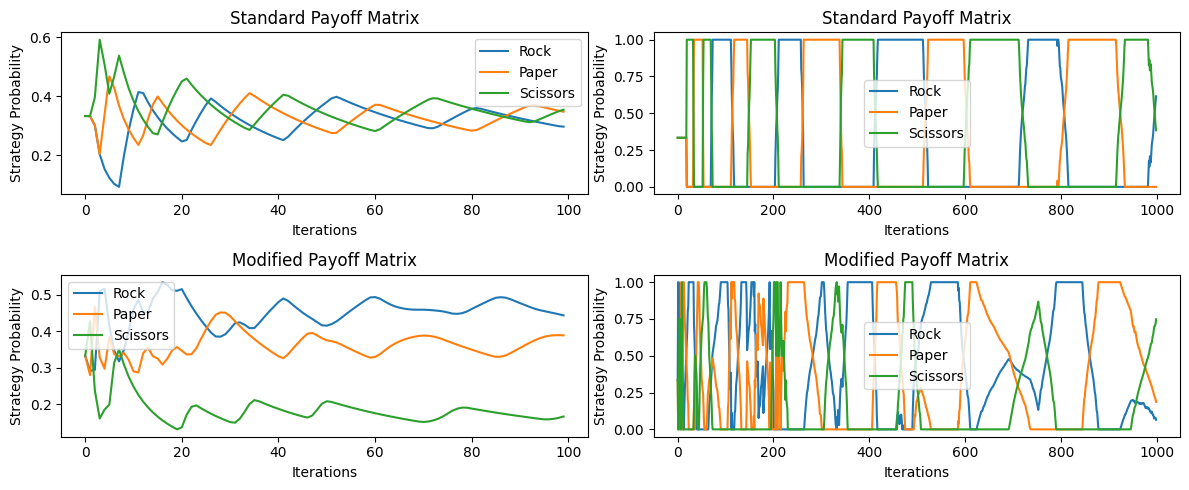

In [ ]:
p1_avg_std, p1_inst_std = simulate_regret_matching(A_std, -A_std.T, 1_000)
p1_avg_mod, p1_inst_mod = simulate_regret_matching(A_mod, -A_mod.T, 1_000)

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
plt.plot(p1_avg_std[:, 0], label='Rock')
plt.plot(p1_avg_std[:, 1], label='Paper')
plt.plot(p1_avg_std[:, 2], label='Scissors')
plt.title("Standard Payoff Matrix")
plt.xlabel("Iterations")
plt.ylabel("Strategy Probability")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(p1_inst_std[:, 0], label='Rock')
plt.plot(p1_inst_std[:, 1], label='Paper')
plt.plot(p1_inst_std[:, 2], label='Scissors')
plt.title("Standard Payoff Matrix")
plt.xlabel("Iterations")
plt.ylabel("Strategy Probability")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(p1_avg_mod[:, 0], label='Rock')
plt.plot(p1_avg_mod[:, 1], label='Paper')
plt.plot(p1_avg_mod[:, 2], label='Scissors')
plt.title("Modified Payoff Matrix")
plt.xlabel("Iterations")
plt.ylabel("Strategy Probability")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(p1_inst_mod[:, 0], label='Rock')
plt.plot(p1_inst_mod[:, 1], label='Paper')
plt.plot(p1_inst_mod[:, 2], label='Scissors')
plt.title("Modified Payoff Matrix")
plt.xlabel("Iterations")
plt.ylabel("Strategy Probability")
plt.legend()

plt.tight_layout()
plt.show()